# RLBench Data Exploration

Explore the HQfang/rlbench-18-tasks episode structure.

**Verified structure**:
- Episodes: `<task>/all_variations/episodes/episode<N>/`
- Images: `front_rgb/0.png`, `1.png`, ... (128x128 uint8 PNGs)
- Low-dim: `low_dim_obs.pkl` — list of `rlbench.backend.observation.Observation`
- `gripper_pose`: `[x, y, z, qx, qy, qz, qw]` — **xyzw** (scipy-native, no reordering)
- Proprio: `joint_positions` (7) + `gripper_open` (1) = 8D

In [1]:
import sys, pickle, pprint
from pathlib import Path
import numpy as np
from PIL import Image

# Allow unpickling Observation without installing rlbench+PyRep+CoppeliaSim
sys.path.insert(0, str(Path("../../").resolve()))
from data_pipeline.conversion.rlbench_obs_stub import register_stub
register_stub()

RLBENCH_ROOT = Path("c:/Users/naqee/OneDrive/Desktop/CSC415 Project/data/raw/rlbench/data/train")
print("Tasks:", sorted([p.name for p in RLBENCH_ROOT.iterdir() if p.is_dir()]))

Tasks: ['close_jar', 'open_drawer', 'slide_block_to_color_target']


In [2]:
# Count episodes per task
for task in ["close_jar", "open_drawer", "slide_block_to_color_target"]:
    ep_dir = RLBENCH_ROOT / task / "all_variations" / "episodes"
    count = sum(1 for d in ep_dir.iterdir() if d.is_dir()) if ep_dir.exists() else 0
    print(f"{task:40s}: {count} episodes")

close_jar                               : 100 episodes
open_drawer                             : 100 episodes
slide_block_to_color_target             : 100 episodes


In [3]:
# Inspect episode0 file layout
ep0 = RLBENCH_ROOT / "close_jar" / "all_variations" / "episodes" / "episode0"
print("Files/dirs in episode0:")
for item in sorted(ep0.iterdir()):
    if item.is_dir():
        n_files = sum(1 for _ in item.iterdir())
        print(f"  {item.name}/  ({n_files} files)")
    else:
        print(f"  {item.name}  ({item.stat().st_size / 1024:.1f} KB)")

Files/dirs in episode0:
  front_depth/  (173 files)
  front_mask/  (173 files)
  front_rgb/  (173 files)
  left_shoulder_depth/  (173 files)
  left_shoulder_mask/  (173 files)
  left_shoulder_rgb/  (173 files)
  low_dim_obs.pkl  (672.9 KB)
  overhead_depth/  (173 files)
  overhead_mask/  (173 files)
  overhead_rgb/  (173 files)
  right_shoulder_depth/  (173 files)
  right_shoulder_mask/  (173 files)
  right_shoulder_rgb/  (173 files)
  variation_descriptions.pkl  (0.2 KB)
  variation_number.pkl  (0.0 KB)
  wrist_depth/  (173 files)
  wrist_mask/  (173 files)
  wrist_rgb/  (173 files)


In [4]:
# Image format
img0 = np.array(Image.open(ep0 / "front_rgb" / "0.png").convert("RGB"))
print(f"Image shape: {img0.shape}, dtype: {img0.dtype}, range: [{img0.min()}, {img0.max()}]")
n_frames = len(list((ep0 / "front_rgb").glob("*.png")))
print(f"Frames in front_rgb: {n_frames}")

Image shape: (128, 128, 3), dtype: uint8, range: [0, 255]
Frames in front_rgb: 173


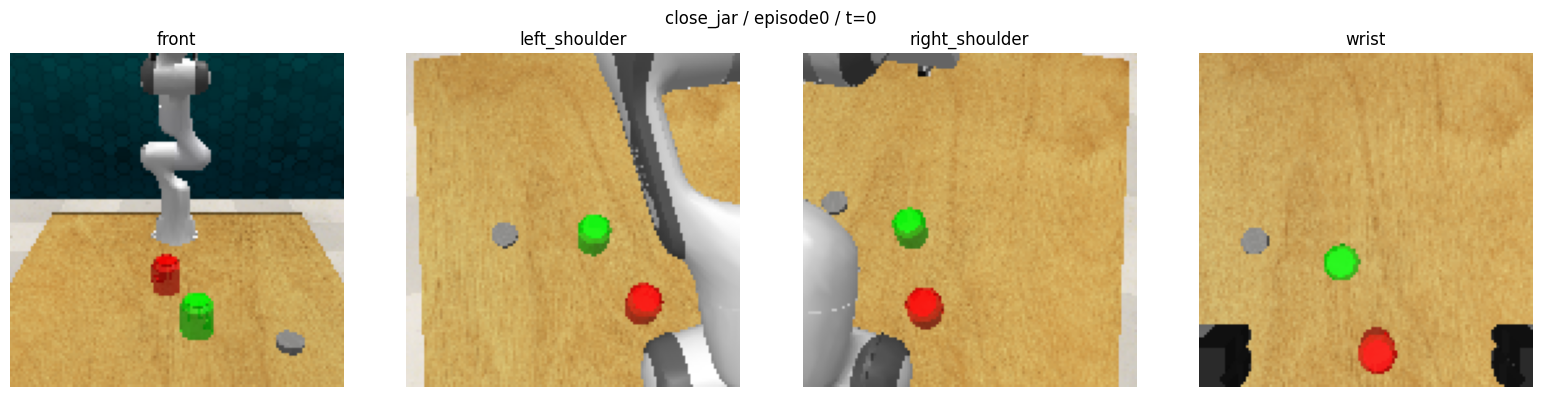

Saved rlbench_cameras.png


In [5]:
# Visualize all 4 cameras at t=0
import matplotlib.pyplot as plt

cams = ["front_rgb", "left_shoulder_rgb", "right_shoulder_rgb", "wrist_rgb"]
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, cam in zip(axes, cams):
    img = np.array(Image.open(ep0 / cam / "0.png").convert("RGB"))
    ax.imshow(img)
    ax.set_title(cam.replace('_rgb', ''))
    ax.axis('off')
plt.suptitle("close_jar / episode0 / t=0")
plt.tight_layout()
plt.savefig("rlbench_cameras.png", dpi=120, bbox_inches='tight')
plt.show()
print("Saved rlbench_cameras.png")

In [6]:
# Load low_dim_obs.pkl
# (rlbench_obs_stub registered above allows this without installing rlbench)
with open(ep0 / "low_dim_obs.pkl", "rb") as f:
    obs_list = pickle.load(f)

print(f"Type: {type(obs_list)}, Length (T): {len(obs_list)}")
obs0 = obs_list[0]
print(f"Obs type: {type(obs0)}")
print(f"Attributes: {sorted(vars(obs0).keys())}")

Type: <class 'data_pipeline.conversion.rlbench_obs_stub.register_stub.<locals>.Demo'>, Length (T): 173
Obs type: <class 'data_pipeline.conversion.rlbench_obs_stub.register_stub.<locals>.Observation'>
Attributes: ['front_depth', 'front_mask', 'front_point_cloud', 'front_rgb', 'gripper_joint_positions', 'gripper_matrix', 'gripper_open', 'gripper_pose', 'gripper_touch_forces', 'ignore_collisions', 'joint_forces', 'joint_positions', 'joint_velocities', 'left_shoulder_depth', 'left_shoulder_mask', 'left_shoulder_point_cloud', 'left_shoulder_rgb', 'misc', 'overhead_depth', 'overhead_mask', 'overhead_point_cloud', 'overhead_rgb', 'right_shoulder_depth', 'right_shoulder_mask', 'right_shoulder_point_cloud', 'right_shoulder_rgb', 'task_low_dim_state', 'wrist_depth', 'wrist_mask', 'wrist_point_cloud', 'wrist_rgb']


In [7]:
# Gripper pose
poses = np.array([obs.gripper_pose for obs in obs_list])  # [T, 7]
print(f"gripper_pose shape: {poses.shape}")
print(f"pose[0]: {poses[0]}")
print()
print("Quaternion part poses[:,3:] norms (should be ~1.0):")
norms = np.linalg.norm(poses[:, 3:], axis=1)
print(f"  min={norms.min():.6f}, max={norms.max():.6f}")
print()
print("Convention check — xyzw: last element is qw")
print(f"  poses[0, -1] = {poses[0, -1]:.4f}  (should be ~1.0 for identity-ish rotation)")

gripper_pose shape: (173, 7)
pose[0]: [ 2.78465480e-01 -8.16017203e-03  1.47196877e+00 -5.35281924e-06
  9.92665172e-01 -4.18133186e-06  1.20896347e-01]

Quaternion part poses[:,3:] norms (should be ~1.0):
  min=1.000000, max=1.000000

Convention check — xyzw: last element is qw
  poses[0, -1] = 0.1209  (should be ~1.0 for identity-ish rotation)


In [8]:
# Verify delta action computation
from scipy.spatial.transform import Rotation as R_

pos  = poses[:, :3]   # [T, 3]
quat = poses[:, 3:]   # [T, 4] xyzw
grip = np.array([float(obs.gripper_open) for obs in obs_list])  # [T]

rots = R_.from_quat(quat)
delta_pos = np.diff(pos, axis=0)                              # [T-1, 3]
delta_rot = (rots[1:] * rots[:-1].inv()).as_rotvec()          # [T-1, 3]
actions   = np.concatenate([delta_pos, delta_rot, grip[:-1, None]], axis=1)  # [T-1, 7]

print(f"Delta actions shape: {actions.shape}")
print(f"delta_pos range: [{delta_pos.min():.4f}, {delta_pos.max():.4f}]")
print(f"delta_rot range: [{delta_rot.min():.4f}, {delta_rot.max():.4f}]")
print(f"gripper values:  {np.unique(grip)}")

Delta actions shape: (172, 7)
delta_pos range: [-0.0212, 0.0218]
delta_rot range: [-0.0507, 0.0077]
gripper values:  [0. 1.]


In [9]:
# Proprio: joint_positions (7) + gripper_open (1)
jp = np.array([obs.joint_positions for obs in obs_list])
print(f"joint_positions shape: {jp.shape}")
proprio = np.concatenate([jp, grip[:, None]], axis=1)
print(f"Proprio [T, 8]: {proprio.shape}")

joint_positions shape: (173, 7)
Proprio [T, 8]: (173, 8)


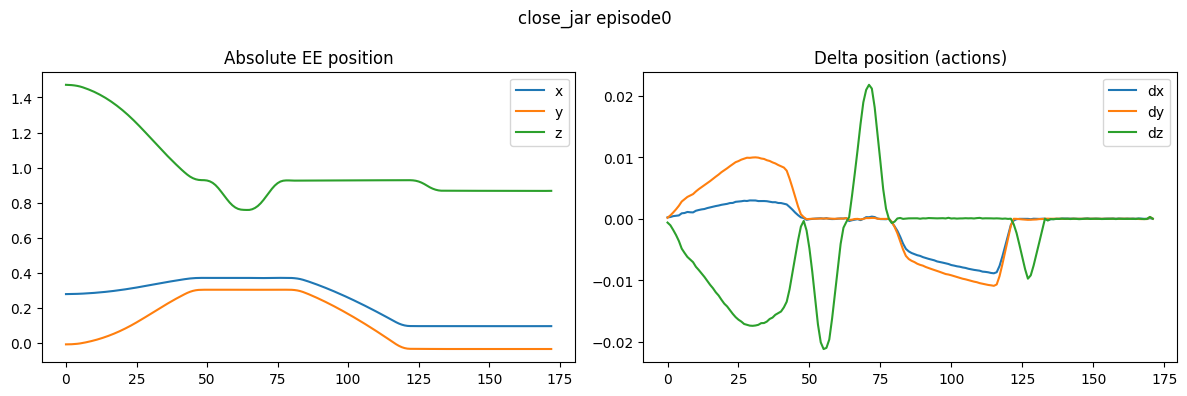

In [10]:
# Plot EE trajectory
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(pos[:, 0], label='x')
axes[0].plot(pos[:, 1], label='y')
axes[0].plot(pos[:, 2], label='z')
axes[0].set_title('Absolute EE position')
axes[0].legend()

axes[1].plot(delta_pos[:, 0], label='dx')
axes[1].plot(delta_pos[:, 1], label='dy')
axes[1].plot(delta_pos[:, 2], label='dz')
axes[1].set_title('Delta position (actions)')
axes[1].legend()
plt.suptitle('close_jar episode0')
plt.tight_layout()
plt.savefig("rlbench_trajectory.png", dpi=120)
plt.show()